In [1]:
import py4DSTEM
import h5py
# %matplotlib widget

# Display the version of py4DSTEM
print(f"py4DSTEM version = {py4DSTEM.__version__}")

py4DSTEM version = 0.14.19


In [2]:
import os
print(os.getcwd())

/Users/louisg/PycharmProjects/m3-learning-m3_learning-dc4a2d5/LTSJ_exp


In [3]:
dirpath = "/Users/louisg/PycharmProjects/m3-learning-m3_learning-dc4a2d5/LTSJ_exp/Datasets/Diffraction_SI/"
filepath_dm4 = dirpath + "Diffraction_SI.dm4"
dc = py4DSTEM.import_file(filepath_dm4)

In [4]:
print(type(dc))
print(dc)

print("\nDatacube object attributes")
print(dir(dc))

print("\nDatacube dimensions")
print(dc.shape)        # print the shape of the data
print(dc.data.shape)   # this is identical to the previous line
print(dc.Rshape)       # print the shape of "real space"
print(dc.Qshape)       # print the shape of "diffraction space"

<class 'py4DSTEM.datacube.datacube.DataCube'>
DataCube( A 4-dimensional array of shape (42, 114, 512, 512) called 'dm_dataset',
          with dimensions:

              Rx = [0.0,0.49195072054862976,0.9839014410972595,...] nm
              Ry = [0.0,0.49195072054862976,0.9839014410972595,...] nm
              Qx = [0.0,0.016712141036987305,0.03342428207397461,...] A^-1
              Qy = [0.0,0.016712141036987305,0.03342428207397461,...] A^-1
)

Datacube object attributes
['Q_Nx', 'Q_Ny', 'Q_pixel_size', 'Q_pixel_units', 'Qshape', 'R_N', 'R_Nx', 'R_Ny', 'R_pixel_size', 'R_pixel_units', 'Rshape', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_add_root_links', '_branch', '_dim_i

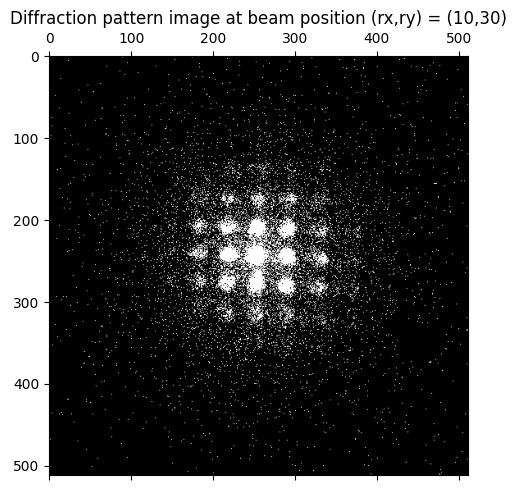

In [5]:
from py4DSTEM import show
# diffraction pattern image at beam position (rx,ry) = (10,30)
dp = dc[10,30]
# Show the image
show(dp, title="Diffraction pattern image at beam position (rx,ry) = (10,30)")

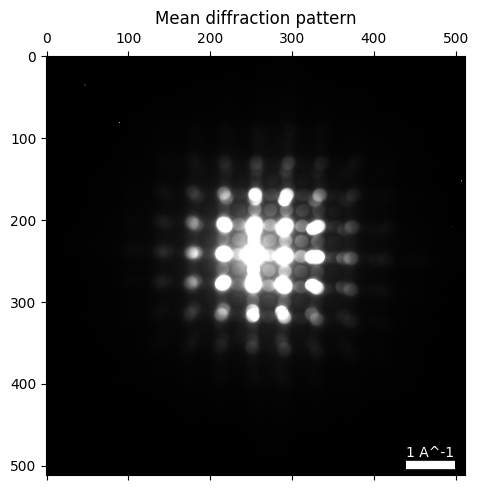

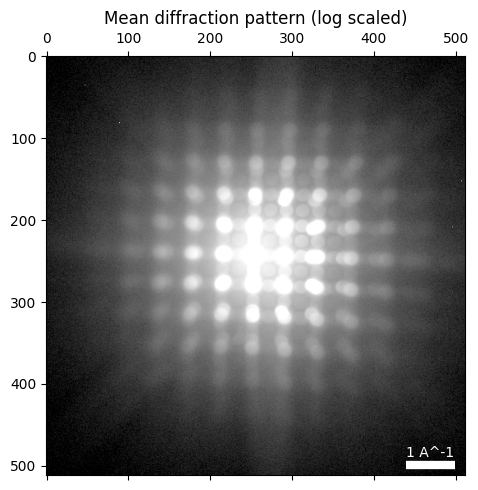

<class 'py4DSTEM.datacube.virtualdiffraction.VirtualDiffraction'>
VirtualDiffraction( A 2-dimensional array of shape (512, 512) called 'dp_mean',
                    with dimensions:

                        dim0 = [0,1,2,...] pixels
                        dim1 = [0,1,2,...] pixels
)


In [6]:
dp_mean = dc.get_dp_mean()
show(
    dp_mean,
    # scaling='log',
    title="Mean diffraction pattern"
)
show(
    dp_mean,
    scaling='log',
    title="Mean diffraction pattern (log scaled)"
)
print(type(dp_mean))
print(dp_mean)

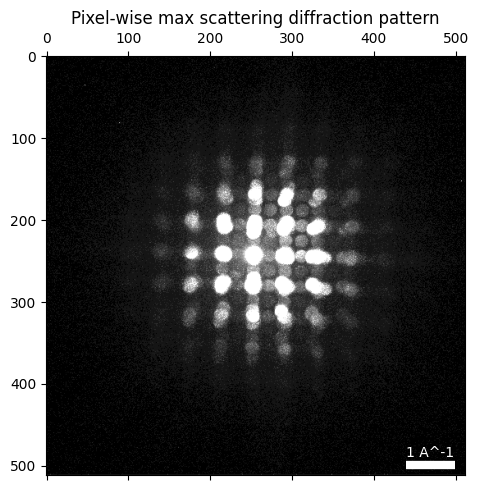

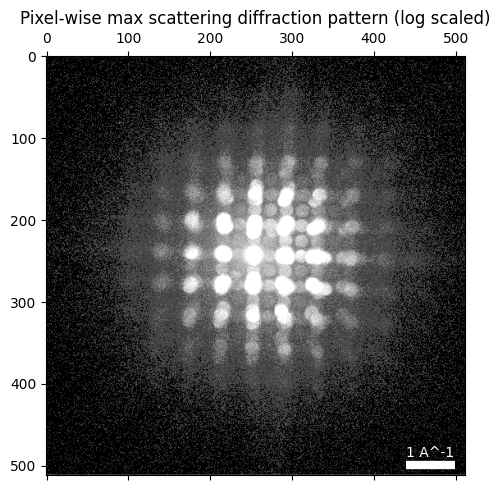

In [7]:
dp_max = dc.get_dp_max()
show(
    dp_max,
    title="Pixel-wise max scattering diffraction pattern"
)
show(
    dp_max,
    scaling='log',
    title="Pixel-wise max scattering diffraction pattern (log scaled)"
)

## Virtual BF imaging

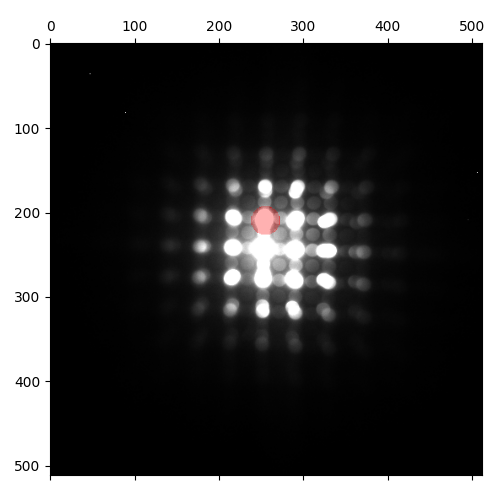

In [23]:
# Position the virtual detector
%matplotlib widget

# set the  geometry
center = (210,255)
radius = 17

geometry_BF = (
    center,
    radius
)


# overlay selected detector position over mean dp
dc.position_detector(
    data = dp_mean,   # this line is optional; without it, the mean diffraction is used, if it's been computed
    mode = 'circle',
    geometry = geometry_BF,
    figsize = (5,5)
)


100%|██████████| 4788/4788 [00:00<00:00, 15067.13it/s]


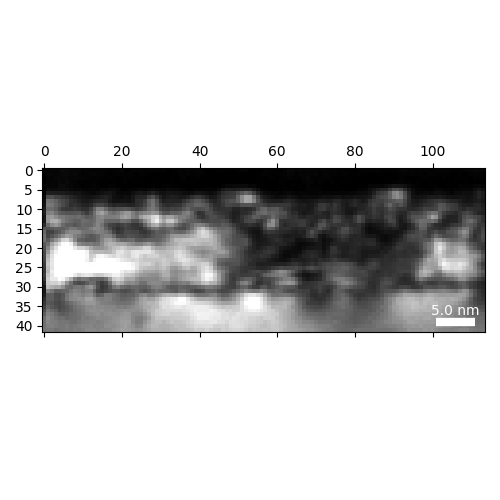

In [24]:
# Capture the virtual BF


# compute
image_BF = dc.get_virtual_image(
    mode = 'circle',
    geometry = (center,radius),
    name = 'bright_field',       # the output will be stored in `datacube`'s tree with this name
)

# show
show(
    image_BF,
    figsize = (5,5)
)

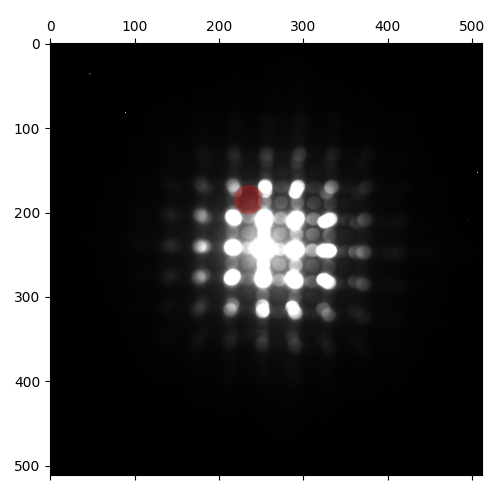

In [25]:
# Position the virtual detector
%matplotlib widget

# set the  geometry
center = (185,235)
radius = 17

geometry_BF = (
    center,
    radius
)


# overlay selected detector position over mean dp
dc.position_detector(
    data = dp_mean,   # this line is optional; without it, the mean diffraction is used, if it's been computed
    mode = 'circle',
    geometry = geometry_BF,
    figsize = (5,5)
)


100%|██████████| 4788/4788 [00:00<00:00, 15081.83it/s]


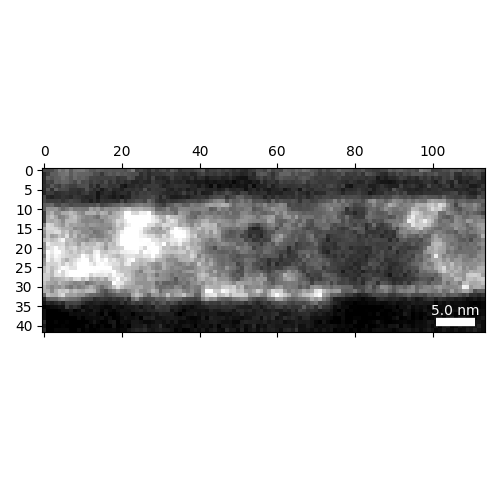

In [26]:
# Capture the virtual BF


# compute
image_BF = dc.get_virtual_image(
    mode = 'circle',
    geometry = (center,radius),
    name = 'bright_field',       # the output will be stored in `datacube`'s tree with this name
)

# show
show(
    image_BF,
    figsize = (5,5)
)

## Virtual DF imaging

In [12]:
# Position the detector


# set the geometry
center = (70,70)
r_inner = 4 * 3
r_outer = 4 * 6

geometry_ADF = (
    center,
    (r_inner,r_outer),
)
    
# overlay selected detector position over mean dp
datacube.position_detector(
    mode = 'annular',
    geometry = geometry_ADF,
    figsize = (5,5)
)

NameError: name 'datacube' is not defined